In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
import tqdm
import sys
import os
import pandas as pd

In [37]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("clip-ViT-B-32")

2026-04-16 18:36:03,409 - INFO - Use pytorch device_name: cpu
2026-04-16 18:36:03,410 - INFO - Load pretrained SentenceTransformer: clip-ViT-B-32
2026-04-16 18:36:03,590 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/clip-ViT-B-32/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-04-16 18:36:03,606 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/clip-ViT-B-32/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/modules.json "HTTP/1.1 200 OK"
2026-04-16 18:36:03,766 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/clip-ViT-B-32/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-04-16 18:36:03,782 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/clip-ViT-B-32/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-04-16 18:36:03,914 - INFO - HTTP Request: HEAD ht

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: /home/kantz/.cache/huggingface/hub/models--sentence-transformers--clip-ViT-B-32/snapshots/327ab6726d33c0e22f920c83f2ff9e4bd38ca37f/0_CLIPModel
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-16 18:36:04,870 - INFO - HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/clip-ViT-B-32 "HTTP/1.1 200 OK"


In [38]:
import dotenv
import os

config = dotenv.dotenv_values(".env")
replace_keys = ["JAVA_HOME", "FUSEKI_HOME"]
append_keys = ["PATH"]
for key, value in config.items():
    # append to os.environ
    if key in append_keys:
        os.environ[key] = f"{os.environ.get(key, '')}:{value}"
    elif key in replace_keys:
        os.environ[key] = value

# check and compare values in fuseki log
os.environ["OPENBLAS_NUM_THREADS"] = "4"

In [39]:
sys.path.append("..")

In [40]:
from utils.datasets import DBPedia
from utils.dbs.qlever_native import QleverDBNative
from utils.dbs.fuseki_native import FusekiDBNative
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import numpy as np
from utils.datasets.base_dataset import DataTensor

In [41]:
dataset = DBPedia(base_dir=Path("./data/dbpedia"))

In [42]:
test_label = "horse"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [43]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.06388352811336517, -0.12784720957279205, -0.18110723793506622, 0.18431150913238525, -0.20080316066741943, 0.15624305605888367, -0.13006766140460968, -1.069543480873108, -0.4048466086387634, 0.36021342873573303, -0.26356494426727295, -0.4461316466331482, 0.05129500851035118, 0.18254637718200684, 0.3010425865650177, 0.022061455994844437, 0.4108300805091858, 0.08453655242919922, -0.16222773492336273, 0.03396514058113098, 0.5115214586257935, 0.10445462167263031, 0.007051737979054451, 0.14695560932159424, -0.42247694730758667, -0.11328865587711334, -0.3804421126842499, 0.4095279574394226, -0.025833647698163986, 0.40274572372436523, -0.09514961391687393, -0.12564995884895325, -0.06016840785741806, 0.38673529028892517, -0.061980873346328735, 0.07894077152013779, -0.13610003888607025, 0.3280862867832184, -0.09309503436088562, 0.11601530015468597, -0.24060288071632385, 0.2583875060081482, 0.1378922462463379, 0.04955071210861206, 0.06715754419565201, 0.23766884207725525, -0.080

In [44]:
db_qlever = QleverDBNative(
    id="qlever",
    base_dir=Path(f"./scratch/{dataset.base_dir.name}"),
    dataset=dataset,
    use_encoded_ttl=True,
    name="QLever",
    port_offset=-100
)
db_no_tensor_idx = QleverDBNative(
    id="qlever",
    base_dir=Path(f"./scratch/{dataset.base_dir.name}"),
    dataset=dataset,
    use_encoded_ttl=True,
    enable_tensor_index=False,
    name="QLever (No Tensor Vocabulary)",
    port_offset=-200
)
db_fuseki = FusekiDBNative(
    id="fuseki",
    base_dir=Path(f"./scratch/{dataset.base_dir.name}"),
    dataset=dataset,
    use_encoded_ttl=True,
    name="Fuseki",
    exec_dir="../../jena-datatensor",
    port_offset=-300
)
possible_queries = db_qlever.get_queries(test_tensor)
print(possible_queries)
dbs: list[QleverDBNative | FusekiDBNative] = [db_qlever, db_no_tensor_idx, db_fuseki]
indices = ["index-encoded", "index-encoded-no-tidx", "fuseki-encoded"]
ids = ["dbpedia-encoded-tidx", "dbpedia-encoded", None]
for db, index, id in zip(dbs, indices, ids):
    db.db_dir = Path("../data/dbpedia") / index
    db.id = id if id is not None else db.id

2026-04-16 18:36:07,054 - WARNING - Killing any existing process using port 25943 before starting the server
2026-04-16 18:36:07,072 - ERROR - Command failed with return code 1
2026-04-16 18:36:07,073 - INFO - Initialized QLeverDBNative with id=qlever, port_id=25943, dataset=DBPedia, name=QLever, use_encoded_ttl=True, endpoint=http://localhost:25943/qlever-with-tidx/sparql
2026-04-16 18:36:07,074 - WARNING - Killing any existing process using port 25844 before starting the server
2026-04-16 18:36:07,092 - ERROR - Command failed with return code 1
2026-04-16 18:36:07,092 - INFO - Initialized QLeverDBNative with id=qlever, port_id=25844, dataset=DBPedia, name=QLever (No Tensor Vocabulary), use_encoded_ttl=True, endpoint=http://localhost:25844/qlever-no-tidx/sparql
2026-04-16 18:36:07,094 - WARNING - Killing any existing process using port 28745 before starting the server
2026-04-16 18:36:07,110 - ERROR - Command failed with return code 1


{<QUERY_DIFFICULTY.EASY: 'easy'>: {<QUERY_TYPE.EMBEDDED: 'embedded'>: '\nPREFIX dbr: <http://dbpedia.org/resource/>\nPREFIX dbo: <http://dbpedia.org/ontology/>\nPREFIX dtf: <https://w3id.org/rdf-tensor/functions#>\nSELECT * WHERE {\n    ?s a dbo:Ship .\n    ?s dbo:thumbnail_embedding ?thumb_emb .\n    ?s dbo:thumbnail_original ?thumb .\n    BIND(dtf:cosineSimilarity(?thumb_emb, "{\\"data\\": [0.06388352811336517, -0.12784720957279205, -0.18110723793506622, 0.18431150913238525, -0.20080316066741943, 0.15624305605888367, -0.13006766140460968, -1.069543480873108, -0.4048466086387634, 0.36021342873573303, -0.26356494426727295, -0.4461316466331482, 0.05129500851035118, 0.18254637718200684, 0.3010425865650177, 0.022061455994844437, 0.4108300805091858, 0.08453655242919922, -0.16222773492336273, 0.03396514058113098, 0.5115214586257935, 0.10445462167263031, 0.007051737979054451, 0.14695560932159424, -0.42247694730758667, -0.11328865587711334, -0.3804421126842499, 0.4095279574394226, -0.02583364

In [45]:
triple_counts = {}
for db in dbs[:-1]:
    with db:
        count = db.get_triple_count()
        triple_counts[db.name] = count
        print(f"{db.name}: {count} triples")
print(f"Total triples in DB: {sum(triple_counts.values())}")

2026-04-16 18:36:07,336 - INFO - Logging QLever setup to scratch/dbpedia/db/qlever-with-tidx/qlever-with-tidx_run.log
2026-04-16 18:36:07,337 - INFO - Loading dataset into QLever server from data/dbpedia/dbpedia_complete.nt.gz
2026-04-16 18:36:07,338 - WARNING - DB directory ../data/dbpedia/index-encoded already exists!
2026-04-16 18:36:07,338 - INFO - Stopping server!
2026-04-16 18:36:07,357 - ERROR - Command failed with return code 1
2026-04-16 18:36:07,357 - INFO - Starting QLever server on port 25943
2026-04-16 18:36:07,358 - INFO - Running command: qlever-server -i dbpedia-encoded-tidx --port 25943 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 18:36:07,360 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)


2026-04-16 18:36:08,361 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 18:36:09,364 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 18:36:10,367 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 18:36:11,380 - INFO - Server is up and responding to queries
2026-04-16 18:36:12,645 - INFO - Stopping server!
2026-04-16 18:36:12,759 - ERROR - Command failed with return code 1
2026-04-16 18:36:12,760 - INFO - Logging QLever setup to scratch/dbpedia/db/qlever-no-tidx/qlever-no-tidx_run.log
2026-04-16 18:36:12,760 - INFO - Loading dataset into QLever server from data/dbpedia/dbpedia_complete.nt.gz
2026-04-16 18:36:12,761 - WARNING - DB directory ../data/dbpedia/index-

QLever: 421770566 triples


2026-04-16 18:36:13,785 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25844/qlever-no-tidx/sparql)
2026-04-16 18:36:14,787 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25844/qlever-no-tidx/sparql)
2026-04-16 18:36:15,788 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25844/qlever-no-tidx/sparql)
2026-04-16 18:36:16,800 - INFO - Server is up and responding to queries
2026-04-16 18:36:18,005 - INFO - Stopping server!
2026-04-16 18:36:18,123 - ERROR - Command failed with return code 1


QLever (No Tensor Vocabulary): 421770566 triples
Total triples in DB: 843541132


In [65]:
with dbs[0] as db:
    res_native = db.query(f"""
PREFIX dbr: <http://dbpedia.org/resource/>
PREFIX dbo: <http://dbpedia.org/ontology/>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
SELECT * WHERE {{


    ?s a dbo:Ship .
    ?s dbo:thumbnail_embedding ?thumb_emb .
    ?s dbo:thumbnail_original ?thumb .      

    BIND(dtf:dotProduct(?thumb_emb, {test_tensor.to_literal().n3()}) AS ?dist)
}} 

ORDER BY DESC(?dist)
LIMIT 10""")
res_native

2026-04-16 18:54:36,803 - INFO - Logging QLever setup to scratch/dbpedia/db/qlever-with-tidx/qlever-with-tidx_run.log
2026-04-16 18:54:36,803 - INFO - Loading dataset into QLever server from data/dbpedia/dbpedia_complete.nt.gz
2026-04-16 18:54:36,804 - WARNING - DB directory ../data/dbpedia/index-encoded already exists!
2026-04-16 18:54:36,805 - INFO - Stopping server!


2026-04-16 18:54:36,916 - ERROR - Command failed with return code 1
2026-04-16 18:54:36,917 - INFO - Starting QLever server on port 25943
2026-04-16 18:54:36,918 - INFO - Running command: qlever-server -i dbpedia-encoded-tidx --port 25943 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 18:54:36,920 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 18:54:37,922 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 18:54:38,924 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 18:54:39,925 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 18:54:40,937 - IN

,s,thumb_emb,thumb,dist
0,dbr:HMS_Trent_(1757,"{""data"": [0.20562176406383514, 0.2037418782711...",https://upload.wikimedia.org/wikipedia/commons...,30.47721099854
1,dbr:I-201-class_submarin,"{""data"": [0.0012263432145118713, -0.0422745048...",https://upload.wikimedia.org/wikipedia/commons...,29.66104888916
2,dbr:I-201-class_submarin,"{""data"": [0.0012263432145118713, -0.0422745048...",https://upload.wikimedia.org/wikipedia/commons...,29.66104888916
3,dbr:German_torpedo_boat_T,"{""data"": [-0.1503494381904602, -0.263388335704...",https://upload.wikimedia.org/wikipedia/commons...,29.35256767273
4,dbr:French_submarine_Redoutable_(1928,"{""data"": [-0.15034939348697662, -0.26338887214...",https://upload.wikimedia.org/wikipedia/commons...,29.35256195068
5,dbr:French_submarine_Redoutable_(1928,"{""data"": [-0.15034939348697662, -0.26338887214...",http://upload.wikimedia.org/wikipedia/commons/...,29.35256195068
6,dbr:French_submarine_Redoutable_(1928,"{""data"": [-0.15034939348697662, -0.26338887214...",https://upload.wikimedia.org/wikipedia/commons...,29.35256195068
7,dbr:French_submarine_Redoutable_(1928,"{""data"": [-0.15034939348697662, -0.26338887214...",https://upload.wikimedia.org/wikipedia/commons...,29.35256195068
8,dbr:I-400-class_submarin,"{""data"": [-0.15034931898117065, -0.26338860392...",http://upload.wikimedia.org/wikipedia/commons/...,29.35255813599
9,dbr:I-400-class_submarin,"{""data"": [-0.15034931898117065, -0.26338860392...",http://upload.wikimedia.org/wikipedia/commons/...,29.35255813599


In [91]:
with dbs[0] as db:
    res =db.query(f"""
PREFIX dbr: <http://dbpedia.org/resource/>
PREFIX dbo: <http://dbpedia.org/ontology/>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
PREFIX tensorSearch: <https://qlever.cs.uni-freiburg.de/tensorSearch/>
SELECT * WHERE {{
SERVICE tensorSearch: {{
    _:config tensorSearch:numNN 10 ;
    tensorSearch:left ?query_vector ;
    tensorSearch:bindDistance ?dist ;
    tensorSearch:payload ?s, ?thumb ;
    tensorSearch:searchK 16 ;
    tensorSearch:nTrees 128 ;
    # tensorSearch:experimentalRightCacheName "easy_index_dbpedia" ;
    tensorSearch:right ?thumb_emb ;
    tensorSearch:algorithm tensorSearch:faiss ;
    tensorSearch:distance tensorSearch:dot .
       {{
            ?s a dbo:Ship ;
            dbo:thumbnail_embedding ?thumb_emb ;
            dbo:thumbnail_original ?thumb .
        }}
    }}
    VALUES (?query_vector) {{ ({test_tensor.to_literal().n3()}) }}
}} 
ORDER BY DESC(?dist)
""")
res

2026-04-16 19:26:58,772 - INFO - Logging QLever setup to scratch/dbpedia/db/qlever-with-tidx/qlever-with-tidx_run.log
2026-04-16 19:26:58,773 - INFO - Loading dataset into QLever server from data/dbpedia/dbpedia_complete.nt.gz
2026-04-16 19:26:58,774 - WARNING - DB directory ../data/dbpedia/index-encoded already exists!
2026-04-16 19:26:58,774 - INFO - Stopping server!
2026-04-16 19:26:58,795 - ERROR - Command failed with return code 1
2026-04-16 19:26:58,796 - INFO - Starting QLever server on port 25943
2026-04-16 19:26:58,796 - INFO - Running command: qlever-server -i dbpedia-encoded-tidx --port 25943 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 19:26:58,798 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 19:26:59,799 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)


,query_vector,dist,s,thumb,thumb_emb
0,"{""data"": [0.06388352811336517, -0.127847209572...",147.3868103027,dbr:1942_Design_Light_Fleet_Carrie,http://upload.wikimedia.org/wikipedia/commons/...,"{""data"": [-0.44762057065963745, 0.103845596313..."
1,"{""data"": [0.06388352811336517, -0.127847209572...",146.494140625,dbr:1942_Design_Light_Fleet_Carrie,https://upload.wikimedia.org/wikipedia/commons...,"{""data"": [-0.12037196755409241, -0.34332275390..."
2,"{""data"": [0.06388352811336517, -0.127847209572...",146.494140625,dbr:1942_Design_Light_Fleet_Carrie,https://upload.wikimedia.org/wikipedia/commons...,"{""data"": [-0.12037196755409241, -0.34332275390..."
3,"{""data"": [0.06388352811336517, -0.127847209572...",146.494140625,dbr:1942_Design_Light_Fleet_Carrie,https://upload.wikimedia.org/wikipedia/commons...,"{""data"": [-0.12037196755409241, -0.34332275390..."
4,"{""data"": [0.06388352811336517, -0.127847209572...",146.494140625,dbr:1942_Design_Light_Fleet_Carrie,http://upload.wikimedia.org/wikipedia/commons/...,"{""data"": [-0.44762057065963745, 0.103845596313..."
5,"{""data"": [0.06388352811336517, -0.127847209572...",146.4343719482,dbr:1942_Design_Light_Fleet_Carrie,http://upload.wikimedia.org/wikipedia/commons/...,"{""data"": [-0.12037196755409241, -0.34332275390..."
6,"{""data"": [0.06388352811336517, -0.127847209572...",146.4343719482,dbr:1942_Design_Light_Fleet_Carrie,https://upload.wikimedia.org/wikipedia/commons...,"{""data"": [-0.12037196755409241, -0.34332275390..."
7,"{""data"": [0.06388352811336517, -0.127847209572...",143.6393127441,dbr:1200-ton_Oil_Fuel_Lighte,https://upload.wikimedia.org/wikipedia/commons...,"{""data"": [0.17403194308280945, -0.098943948745..."
8,"{""data"": [0.06388352811336517, -0.127847209572...",143.6393127441,dbr:120ft_Motor_Lighte,http://upload.wikimedia.org/wikipedia/commons/...,"{""data"": [0.11573639512062073, -0.556233942508..."
9,"{""data"": [0.06388352811336517, -0.127847209572...",143.6393127441,dbr:1942_Design_Light_Fleet_Carrie,http://upload.wikimedia.org/wikipedia/commons/...,"{""data"": [-0.12037196755409241, -0.34332275390..."


In [84]:
res.to_csv(Path("scratch") / "dbpedia_results_index.csv", index=False)

In [92]:
def precision(gt:pd.Series, retrieved:pd.Series, k=20):
    gt_set = set(gt[:k])
    retrieved_set = set(retrieved[:k])
    return len(gt_set.intersection(retrieved_set)) / len(gt_set)
def recall(gt:pd.Series, retrieved:pd.Series, k=20):
    gt_set = set(gt[:k])
    retrieved_set = set(retrieved[:k])
    return len(gt_set.intersection(retrieved_set)) / len(gt_set)
def f1_score(gt:pd.Series, retrieved:pd.Series, k=20):
    p = precision(gt, retrieved, k)
    r = recall(gt, retrieved, k)
    if p + r == 0:
        return 0.0
    return 2 * (p * r) / (p + r)
precision(res_native["s"], res["s"], k=10)

0.0

In [93]:
# count ships
with dbs[0] as db:
    rc =db.query(f"""
PREFIX dbr: <http://dbpedia.org/resource/>
PREFIX dbo: <http://dbpedia.org/ontology/>
SELECT * WHERE {{ 
            ?s a dbo:Ship ;
            dbo:thumbnail_embedding ?thumb_emb ;
            dbo:thumbnail_original ?thumb  .
}} LIMIT 10""")
rc

2026-04-16 19:29:16,158 - INFO - Logging QLever setup to scratch/dbpedia/db/qlever-with-tidx/qlever-with-tidx_run.log
2026-04-16 19:29:16,159 - INFO - Loading dataset into QLever server from data/dbpedia/dbpedia_complete.nt.gz
2026-04-16 19:29:16,159 - WARNING - DB directory ../data/dbpedia/index-encoded already exists!
2026-04-16 19:29:16,160 - INFO - Stopping server!
2026-04-16 19:29:16,181 - ERROR - Command failed with return code 1
2026-04-16 19:29:16,181 - INFO - Starting QLever server on port 25943
2026-04-16 19:29:16,181 - INFO - Running command: qlever-server -i dbpedia-encoded-tidx --port 25943 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 19:29:16,183 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)


2026-04-16 19:29:17,184 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 19:29:18,186 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:25943/qlever-with-tidx/sparql)
2026-04-16 19:29:19,197 - INFO - Server is up and responding to queries
2026-04-16 19:29:48,644 - INFO - Stopping server!
2026-04-16 19:29:48,828 - ERROR - Command failed with return code 1


KeyboardInterrupt: 

In [ ]:
import time
from PIL import Image
from io import BytesIO
import requests

import hashlib


def get_wc_thumb(image: str, width=330):  # image = e.g. from Wikidata, width in pixels
    image_name = image.split("/")[-1]
    print(f"Fetching thumbnail for {image_name}...")
    image_name = image_name.replace(" ", "_")  # need to replace spaces with underline
    m = hashlib.md5()
    m.update(image_name.encode("utf-8"))
    d = m.hexdigest()
    return (
        "https://upload.wikimedia.org/wikipedia/commons/thumb/"
        + d[0]
        + "/"
        + d[0:2]
        + "/"
        + image_name
        + "/"
        + str(width)
        + "px-"
        + image_name
    )


def thumbs_to_pil(thumbs: pd.Series):

    pil_images = []
    for thumb in thumbs:
        url_thumb = get_wc_thumb(thumb)
        try:
            response = None
            while response is None or response.status_code == 429:  # Too Many Requests
                response = requests.get(
                    url_thumb, headers={"User-Agent": "Qlever Image Viewer/1.0"}
                )
                if response.status_code == 429:
                    waiting_time = response.headers.get("Retry-After", 1)
                    print(
                        f"Rate limited when fetching {url_thumb}, retrying after {waiting_time} seconds..."
                    )
                    time.sleep(int(waiting_time))
            img = Image.open(BytesIO(response.content))
            pil_images.append(img)
        except Exception as e:
            print(f"Error loading image {url_thumb}: {e}")
            pil_images.append(None)
    return pd.Series(pil_images, index=thumbs.index)


res["pil_thumb"] = thumbs_to_pil(res["thumb"])
res

Fetching thumbnail for Carysfort_cropped.jpg...
Fetching thumbnail for Statue_of_Chhatrapati_Shivaji_at_Pratapgad%2C_Maharashtra%2C_India.jpg...
Error loading image https://upload.wikimedia.org/wikipedia/commons/thumb/4/49/Statue_of_Chhatrapati_Shivaji_at_Pratapgad%2C_Maharashtra%2C_India.jpg/330px-Statue_of_Chhatrapati_Shivaji_at_Pratapgad%2C_Maharashtra%2C_India.jpg: cannot identify image file <_io.BytesIO object at 0x7f0598b4d4e0>
Fetching thumbnail for Pratapgad_The_Fort_of_Valour.jpg...
Fetching thumbnail for Hms-unicorn-close-up.jpg...
Rate limited when fetching https://upload.wikimedia.org/wikipedia/commons/thumb/1/1c/Hms-unicorn-close-up.jpg/330px-Hms-unicorn-close-up.jpg, retrying after 1 seconds...
Rate limited when fetching https://upload.wikimedia.org/wikipedia/commons/thumb/1/1c/Hms-unicorn-close-up.jpg/330px-Hms-unicorn-close-up.jpg, retrying after 1 seconds...
Rate limited when fetching https://upload.wikimedia.org/wikipedia/commons/thumb/1/1c/Hms-unicorn-close-up.jpg/33

,s,thumb_emb,thumb,dist,pil_thumb
0,dbr:HMS_Trent_(1757,"{""data"": [0.20562176406383514, 0.2037418782711...",https://upload.wikimedia.org/wikipedia/commons...,0.2657939195633,<PIL.JpegImagePlugin.JpegImageFile image mode=...
1,dbr:Pratapga,"{""data"": [-0.7242363691329956, 0.5072268843650...",https://upload.wikimedia.org/wikipedia/commons...,0.2612751126289,None
2,dbr:Pratapga,"{""data"": [-0.7242363691329956, 0.5072268843650...",https://upload.wikimedia.org/wikipedia/commons...,0.2612751126289,<PIL.JpegImagePlugin.JpegImageFile image mode=...
3,dbr:HMS_Unicorn_(1824,"{""data"": [0.019780755043029785, 0.559137046337...",https://upload.wikimedia.org/wikipedia/commons...,0.2584769129753,<PIL.JpegImagePlugin.JpegImageFile image mode=...
4,dbr:HMS_Unicorn_(1824,"{""data"": [0.019780755043029785, 0.559137046337...",https://upload.wikimedia.org/wikipedia/commons...,0.2584769129753,None


,s,thumb,pil_thumb
0,dbr:HMS_Trent_(1757,https://upload.wikimedia.org/wikipedia/commons/b/b0/Carysfort_cropped.jpg,
1,dbr:Pratapga,https://upload.wikimedia.org/wikipedia/commons/d/db/Statue_of_Chhatrapati_Shivaji_at_Pratapgad%2C_Maharashtra%2C_India.jpg,None
2,dbr:Pratapga,https://upload.wikimedia.org/wikipedia/commons/c/ca/Pratapgad_The_Fort_of_Valour.jpg,
3,dbr:HMS_Unicorn_(1824,https://upload.wikimedia.org/wikipedia/commons/1/1c/Hms-unicorn-close-up.jpg,
4,dbr:HMS_Unicorn_(1824,https://upload.wikimedia.org/wikipedia/commons/9/97/HM_Frigate_Unicorn%2C_from_the_stern_-_geograph.org.uk_-_1316939.jpg,None

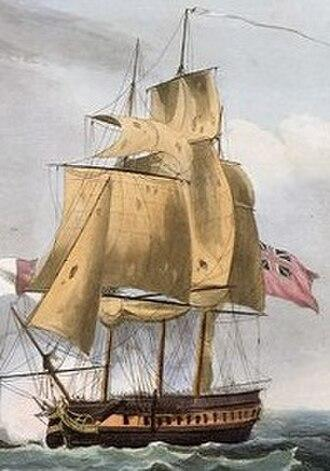
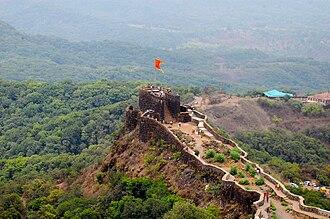
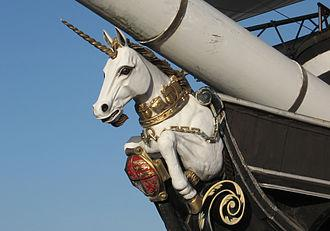

In [ ]:
# https://stackoverflow.com/a/55194315
import base64
from IPython.display import HTML
def image_base64(im: Image):
    with BytesIO() as buffer:
        if im.mode in ("RGBA", "P"):
            im = im.convert("RGB")
        im.save(buffer, 'jpeg')
        return base64.b64encode(buffer.getvalue()).decode()
def image_formatter(im):
    return f'<img src="data:image/jpeg;base64,{image_base64(im)}" width="300px">'

HTML(res[["s", "thumb", "pil_thumb"]].to_html(formatters={'pil_thumb': image_formatter}, escape=False))


In [ ]:
import time

with db_no_tensor_idx as db:
    timings = []
    for _ in tqdm.tqdm(range(10)):
        start_time = time.time()
        noised_tensor = test_tensor.to_numpy() + np.random.normal(scale=0.01, size=test_tensor.to_numpy().shape)
        noised_tensor = DataTensor.from_numpy(noised_tensor)

        results = db.query_auto(
            noised_tensor,
            query_difficulty=QUERY_DIFFICULTY.EASY,
            query_type=QUERY_TYPE.EMBEDDED,
        )
        elapsed_time = time.time() - start_time
        timings.append(elapsed_time)
print("Median elapsed time:", np.median(timings))
results

2026-04-16 11:57:41,194 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-16 11:57:41,210 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-no-tidx already exists!
2026-04-16 11:57:41,210 - INFO - Stopping server!


2026-04-16 11:57:41,214 - INFO - Starting QLever server on port 8031
2026-04-16 11:57:41,215 - INFO - Running command: qlever-server -i test-no-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 11:57:41,217 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-no-tidx/sparql)
2026-04-16 11:57:42,252 - INFO - Server is up and responding to queries
100%|██████████| 10/10 [00:01<00:00,  5.09it/s]
2026-04-16 11:57:44,219 - INFO - Stopping server!


Median elapsed time: 0.18390440940856934


,product,vector,dist
0,bsbmi:ProductFeature55,"{""data"": [0.009423847310245037, -0.01557747554...",0.3056965768337
1,bsbmi:ProductFeature28,"{""data"": [0.010077591054141521, -0.07332565635...",0.2821191251278
2,bsbmi:ProductFeature91,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2771179676056
3,bsbmi:ProductFeature80,"{""data"": [0.06109052151441574, -0.086534291505...",0.2677884995937
4,bsbmi:ProductFeature87,"{""data"": [0.018030863255262375, 0.051510427147...",0.2660349905491
5,bsbmi:dataFromProducer2/Product8,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2615694105625
6,bsbmi:ProductType1,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2459843754768
7,bsbmi:dataFromProducer1/Product,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2444776147604
8,bsbmi:ProductFeature58,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2369430065155
9,bsbmi:ProductFeature18,"{""data"": [0.0023775286972522736, -0.0391830988...",0.2275364845991


In [ ]:
with db:
    possible_queries = db.get_queries(test_tensor)
    results = db.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.INDEX])
results

2026-04-16 11:06:12,448 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-16 11:06:12,449 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-with-tidx already exists!
2026-04-16 11:06:12,449 - INFO - Stopping server!
2026-04-16 11:06:12,450 - INFO - Starting QLever server on port 8031
2026-04-16 11:06:12,450 - INFO - Running command: qlever-server -i test-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 11:06:12,452 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-with-tidx/sparql)


2026-04-16 11:06:13,463 - INFO - Server is up and responding to queries
2026-04-16 11:06:13,596 - INFO - Stopping server!


,product,vector,dist
0,bsbmi:ProductFeature55,"{""data"": [0.009423847310245037, -0.01557747554...",1.366928339005
1,bsbmi:ProductFeature28,"{""data"": [0.010077591054141521, -0.07332565635...",1.412792205811
2,bsbmi:ProductFeature91,"{""data"": [0.0399559922516346, 0.04019024968147...",1.426476240158
3,bsbmi:ProductFeature80,"{""data"": [0.06109052151441574, -0.086534291505...",1.440332531929
4,bsbmi:ProductFeature87,"{""data"": [0.018030863255262375, 0.051510427147...",1.471283555031
5,bsbmi:dataFromProducer2/Product8,"{""data"": [0.03998035192489624, 0.0118160368874...",1.472614526749
6,bsbmi:ProductType1,"{""data"": [-0.07872356474399567, 0.087168984115...",1.479606389999
7,bsbmi:dataFromProducer1/Product,"{""data"": [-0.0035400420892983675, 0.0261042360...",1.481603384018
8,bsbmi:ProductFeature58,"{""data"": [-0.05134187638759613, -0.03562515974...",1.518724322319
9,bsbmi:ProductFeature66,"{""data"": [0.07709012180566788, 0.0770644396543...",1.51947927475


In [ ]:
with db_fuseki:
    possible_queries = db_fuseki.get_queries(test_tensor)
    results = db_fuseki.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-04-16 11:06:13,739 - INFO - Loading dataset into Fuseki server from data/bsbm_2/dataset.nt
2026-04-16 11:06:13,741 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test_fuseki already exists, removing locks if any
2026-04-16 11:06:13,741 - INFO - Stopping server!
2026-04-16 11:06:13,742 - INFO - Starting Fuseki server port 7031
2026-04-16 11:06:13,742 - ERROR - TENSOR_CP environment variable is not set
2026-04-16 11:06:13,743 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-16 11:06:13,743 - ERROR - FUSEKI_HOME environment variable is not set
2026-04-16 11:06:13,744 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-04-16 11:06:13,744 - INFO - Using FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0 and TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-16 11:06:13,746 - INFO - Waiting for server to start..., got error: <urlopen error [Errno

2026-04-16 11:06:15,468 - INFO - Server is up and responding to queries
2026-04-16 11:06:16,905 - INFO - Stopping server!


,product,vector,dist
0,bsbmi:ProductFeature55,"{""data"": [0.009423847310245037, -0.01557747554...",0.31653597950935364
1,bsbmi:ProductFeature28,"{""data"": [0.010077591054141521, -0.07332565635...",0.29360419511795044
2,bsbmi:ProductFeature91,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163147
3,bsbmi:ProductFeature80,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798336446285248
4,bsbmi:ProductFeature87,"{""data"": [0.018030863255262375, 0.051510427147...",0.26435840129852295
5,bsbmi:dataFromProducer2/Product8,"{""data"": [0.03998035192489624, 0.0118160368874...",0.2636927366256714
6,bsbmi:ProductType1,"{""data"": [-0.07872356474399567, 0.087168984115...",0.26019686460494995
7,bsbmi:dataFromProducer1/Product,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.25919830799102783
8,bsbmi:ProductFeature58,"{""data"": [-0.05134187638759613, -0.03562515974...",0.24063780903816223
9,bsbmi:ProductFeature66,"{""data"": [0.07709012180566788, 0.0770644396543...",0.24026034772396088


In [ ]:
with db_no_tensor_idx:
    possible_queries = db_no_tensor_idx.get_queries(test_tensor)
    results = db_no_tensor_idx.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-04-16 11:06:17,176 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-16 11:06:17,177 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-no-tidx already exists!
2026-04-16 11:06:17,178 - INFO - Stopping server!
2026-04-16 11:06:17,179 - INFO - Starting QLever server on port 8031
2026-04-16 11:06:17,179 - INFO - Running command: qlever-server -i test-no-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 11:06:17,181 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-no-tidx/sparql)


2026-04-16 11:06:18,193 - INFO - Server is up and responding to queries
2026-04-16 11:06:18,255 - INFO - Stopping server!


,product,vector,dist
0,bsbmi:ProductFeature55,"{""data"": [0.009423847310245037, -0.01557747554...",0.3165358603001
1,bsbmi:ProductFeature28,"{""data"": [0.010077591054141521, -0.07332565635...",0.2936039566994
2,bsbmi:ProductFeature91,"{""data"": [0.0399559922516346, 0.04019024968147...",0.2867618203163
3,bsbmi:ProductFeature80,"{""data"": [0.06109052151441574, -0.086534291505...",0.2798337340355
4,bsbmi:ProductFeature87,"{""data"": [0.018030863255262375, 0.051510427147...",0.2643582224846
5,bsbmi:dataFromProducer2/Product8,"{""data"": [0.03998035192489624, 0.0118160368874...",0.263692855835
6,bsbmi:ProductType1,"{""data"": [-0.07872356474399567, 0.087168984115...",0.2601968050003
7,bsbmi:dataFromProducer1/Product,"{""data"": [-0.0035400420892983675, 0.0261042360...",0.2591982781887
8,bsbmi:ProductFeature58,"{""data"": [-0.05134187638759613, -0.03562515974...",0.2406378388405
9,bsbmi:ProductFeature66,"{""data"": [0.07709012180566788, 0.0770644396543...",0.2402603030205


In [ ]:
import os
os.environ["PATH"]

'/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/.venv/bin:/nfsd/gracedata2/kantz/Dense-Vector-KG/qlever/build/release:/home/kantz/apache-jena-fuseki-5.2.0:/home/kantz/apache-jena-5.2.0/bin:/home/kantz/miniconda3/envs/qlever/bin:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/debugCommand:/home/kantz/.vscode-server/data/User/globalStorage/github.copilot-chat/copilotCli:/home/kantz/.vscode-server/cli/servers/Stable-cfbea10c5ffb233ea9177d34726e6056e89913dc/server/bin/remote-cli:/home/kantz/bin:/home/kantz/bin:/home/kantz/.local/bin:/usr/share/Modules/bin:/usr/condabin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/usr/java/latest/bin:/usr/lib/scala/bin:/usr/local/spark-2.3.2-bin-hadoop2.7/bin:/home/kantz/.vscode-server/extensions/ms-python.debugpy-2025.18.0-linux-x64/bundled/scripts/noConfigScripts:/home/kantz/.vscode-server/cli/servers/Stabl

In [ ]:
with db:
    count=db.query("SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }")
print(count)

2026-04-16 11:06:20,101 - INFO - Loading dataset into QLever server from data/bsbm_2/dataset.nt
2026-04-16 11:06:20,103 - WARNING - DB directory scratch/bsbm/bsbm_2/db/test-with-tidx already exists!
2026-04-16 11:06:20,104 - INFO - Stopping server!
2026-04-16 11:06:20,105 - INFO - Starting QLever server on port 8031
2026-04-16 11:06:20,105 - INFO - Running command: qlever-server -i test-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 11:06:20,107 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/test-with-tidx/sparql)


2026-04-16 11:06:21,121 - INFO - Server is up and responding to queries
2026-04-16 11:06:21,130 - INFO - Stopping server!


   count
0  42417


## Try some timings!

In [ ]:
import pandas as pd

from utils.dbs.base_docker import BaseDocker
from utils.bench import BenchmarkRunner

timings_df = pd.DataFrame()
stats_df = pd.DataFrame()
for power, size in zip(powers, sizes):
    difficulties = [
        # QUERY_DIFFICULTY.HARD,
        QUERY_DIFFICULTY.EASY,
    ]
    if power > 1:
        difficulties = [QUERY_DIFFICULTY.EASY]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDocker] = [
        FusekiDBNative(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
            enable_tensor_index=True,
            name="Qlever",
        ),
        QleverDBNative(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
            enable_tensor_index=False,
            name="Qlever (no Tensor Vocabulary)",
        ),
    ]
    reference_db = dbs[0]
    reference_results: dict[QUERY_DIFFICULTY, pd.DataFrame] = {}
    for difficulty in difficulties:
        with reference_db:
            reference_result = reference_db.query_auto(
                test_tensor,
                query_difficulty=difficulty,
                query_type=QUERY_TYPE.EMBEDDED,
            )
            reference_results[difficulty] = reference_result
    bench = BenchmarkRunner(
        dbs=dbs,
        test_tensor=test_tensor,
        difficulties=difficulties,
        types=[
            QUERY_TYPE.EMBEDDED,
            # QUERY_TYPE.INDEX,
        ],
        dataset=dataset,
        reference_results=reference_results,
    )
    result = bench.run_benchmark(repetitions=16)
    timings_df = pd.concat([timings_df, result.timings], ignore_index=True)
    stats_df = pd.concat([stats_df, result.stats], ignore_index=True)

2026-04-16 11:06:24,865 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=Qlever, use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever-with-tidx/sparql
2026-04-16 11:06:24,866 - INFO - Initialized QLeverDBNative with id=timing-qlever, port_id=8031, dataset=bsbm, name=Qlever (no Tensor Vocabulary), use_encoded_ttl=True, endpoint=http://localhost:8031/timing-qlever-no-tidx/sparql
2026-04-16 11:06:24,867 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt
2026-04-16 11:06:24,867 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-fuseki already exists, removing locks if any
2026-04-16 11:06:24,868 - INFO - Stopping server!
2026-04-16 11:06:24,868 - INFO - Starting Fuseki server port 7031
2026-04-16 11:06:24,869 - ERROR - TENSOR_CP environment variable is not set
2026-04-16 11:06:24,869 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-16 11:

Running BDSDM timing for size 1...


2026-04-16 11:06:25,873 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)


2026-04-16 11:06:32,511 - INFO - Server is up and responding to queries
2026-04-16 11:06:40,107 - INFO - Stopping server!
2026-04-16 11:06:40,242 - INFO - Loading dataset into Fuseki server from data/bsbm_0/dataset.nt
2026-04-16 11:06:40,273 - WARNING - DB directory scratch/bsbm/bsbm_0/db/timing-fuseki already exists, removing locks if any
2026-04-16 11:06:40,291 - INFO - Stopping server!
2026-04-16 11:06:40,298 - INFO - Starting Fuseki server port 7031
2026-04-16 11:06:40,310 - WARNING - Server is already running, stopping it first
2026-04-16 11:06:40,314 - INFO - Stopping server!
2026-04-16 11:06:40,322 - ERROR - TENSOR_CP environment variable is not set
2026-04-16 11:06:40,337 - INFO - Using default TENSOR_CP=/nfsd/gracedata2/kantz/Dense-Vector-KG/jena-datatensor/jena-datatensor/target/*
2026-04-16 11:06:40,342 - ERROR - FUSEKI_HOME environment variable is not set
2026-04-16 11:06:40,405 - INFO - Using default FUSEKI_HOME=/home/kantz/apache-jena-fuseki-5.2.0
2026-04-16 11:06:40,447 

Running benchmark for FusekiDB + RDFTensor, difficulty easy, query type embedded


...

2026-04-16 11:09:35,982 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:7031/timing-fuseki/sparql)
2026-04-16 11:09:46,393 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db FusekiDB + RDFTensor: 100%|██████████| 16/16 [01:13<00:00,  4.62s/it]
2026-04-16 11:11:01,619 - INFO - Stopping server!
2026-04-16 11:11:01,620 - INFO - Loading dataset into QLever server from data/bsbm_4/dataset.nt
2026-04-16 11:11:01,621 - WARNING - DB directory scratch/bsbm/bsbm_4/db/timing-qlever-with-tidx already exists!
2026-04-16 11:11:01,622 - INFO - Stopping server!
2026-04-16 11:11:01,622 - INFO - Starting QLever server on port 8031
2026-04-16 11:11:01,624 - INFO - Running command: qlever-server -i timing-qlever-with-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 11:11:01,626 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111

Running benchmark for Qlever, difficulty easy, query type embedded


2026-04-16 11:11:02,643 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db Qlever: 100%|██████████| 16/16 [00:26<00:00,  1.64s/it]
2026-04-16 11:11:29,006 - INFO - Stopping server!
2026-04-16 11:11:29,009 - INFO - Loading dataset into QLever server from data/bsbm_4/dataset.nt
2026-04-16 11:11:29,011 - WARNING - DB directory scratch/bsbm/bsbm_4/db/timing-qlever-no-tidx already exists!
2026-04-16 11:11:29,012 - INFO - Stopping server!
2026-04-16 11:11:29,013 - INFO - Starting QLever server on port 8031
2026-04-16 11:11:29,017 - INFO - Running command: qlever-server -i timing-qlever-no-tidx --port 8031 -k 0 -m 8G --tensor-search-max-num-threads 4
2026-04-16 11:11:29,019 - INFO - Waiting for server to start..., got error: <urlopen error [Errno 111] Connection refused> (http://localhost:8031/timing-qlever-no-tidx/sparql)


Running benchmark for Qlever (no Tensor Vocabulary), difficulty easy, query type embedded


2026-04-16 11:11:30,045 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db Qlever (no Tensor Vocabulary): 100%|██████████| 16/16 [00:40<00:00,  2.53s/it]
2026-04-16 11:12:10,754 - INFO - Stopping server!


In [ ]:
timings_df

,size,power,estimated_size,elapsed_time,rep,engine,difficulty,query_type,ndcg_score
0,2418,3,1,1.066530,0,FusekiDB + RDFTensor,easy,embedded,1.0
1,2418,3,1,0.085307,1,FusekiDB + RDFTensor,easy,embedded,1.0
2,2418,3,1,0.064670,2,FusekiDB + RDFTensor,easy,embedded,1.0
3,2418,3,1,0.052921,3,FusekiDB + RDFTensor,easy,embedded,1.0
4,2418,3,1,0.058497,4,FusekiDB + RDFTensor,easy,embedded,1.0
...,...,...,...,...,...,...,...,...,...
235,3577077,6,10000,2.173352,11,Qlever (no Tensor Vocabulary),easy,embedded,1.0
236,3577077,6,10000,3.810047,12,Qlever (no Tensor Vocabulary),easy,embedded,1.0
237,3577077,6,10000,2.284885,13,Qlever (no Tensor Vocabulary),easy,embedded,1.0
238,3577077,6,10000,3.026799,14,Qlever (no Tensor Vocabulary),easy,embedded,1.0


In [ ]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<ArrowStringArray>
['FusekiDB + RDFTensor', 'Qlever', 'Qlever (no Tensor Vocabulary)']
Length: 3, dtype: str

In [ ]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [ ]:
groupings = timings_df.groupby(["estimated_size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [ ]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'FusekiDB + RDFTensor': 'C0',
 'Qlever': 'C1',
 'Qlever (no Tensor Vocabulary)': 'C2'}

/tmp/ipykernel_4082075/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


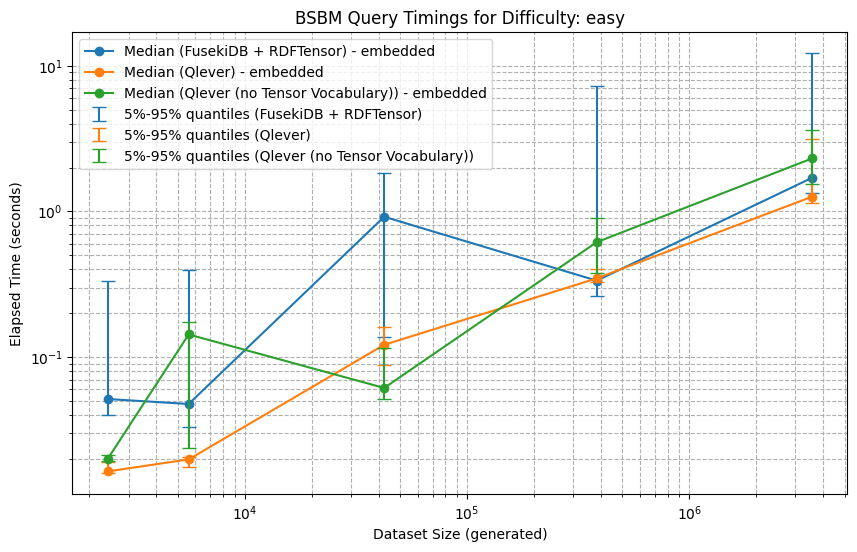

In [ ]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, df, engine, difficulty, relevant_measure="elapsed_time"):
    groupings = df.groupby(["size", "engine", "difficulty", "query_type"])[
        relevant_measure
    ]
    quantiles = [0.05, 0.95]
    median_timings = groupings.median().reset_index()
    quantile_timings = groupings.quantile(quantiles).unstack().reset_index()
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["size"],
                engine_median[relevant_measure],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["size"],
                engine_median[relevant_measure],
                yerr=[
                    engine_median[relevant_measure] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median[relevant_measure],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, timings_df, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (generated)")
    ax.set_ylabel("Elapsed Time (seconds)")
    ax.set_title(f"BSBM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_timings.png")
plt.show()

In [ ]:
stats_df

,timestamp,cpu_percent,mem_usage,net_io,block_io,pids,size,power,difficulty,query_type,estimated_size,engine
0,2026-04-16 11:06:46.112888,0.0,341475328,-1,21831123,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
1,2026-04-16 11:06:46.246058,653.7,369197056,-1,22741939,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
2,2026-04-16 11:06:46.379754,411.4,384532480,-1,23432475,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
3,2026-04-16 11:06:46.513199,936.7,419713024,-1,23929005,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
4,2026-04-16 11:06:46.651644,1199.0,429944832,-1,24515799,1,2418,3,easy,embedded,1,FusekiDB + RDFTensor
...,...,...,...,...,...,...,...,...,...,...,...,...
790,2026-04-16 11:12:09.940336,52.9,87859200,-1,1940722829,1,3577077,6,easy,embedded,10000,Qlever (no Tensor Vocabulary)
791,2026-04-16 11:12:10.113336,46.2,87859200,-1,1948253073,1,3577077,6,easy,embedded,10000,Qlever (no Tensor Vocabulary)
792,2026-04-16 11:12:10.285837,58.0,87859200,-1,1955839299,1,3577077,6,easy,embedded,10000,Qlever (no Tensor Vocabulary)
793,2026-04-16 11:12:10.467338,44.1,87859200,-1,1964037643,1,3577077,6,easy,embedded,10000,Qlever (no Tensor Vocabulary)


In [ ]:
stats_df["cpu_percent"] = stats_df["cpu_percent"].astype(float)
stats_df["mem_usage_mb"] = stats_df["mem_usage"].astype(float) / (1024 * 1024)  # in MiB

/tmp/ipykernel_4082075/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


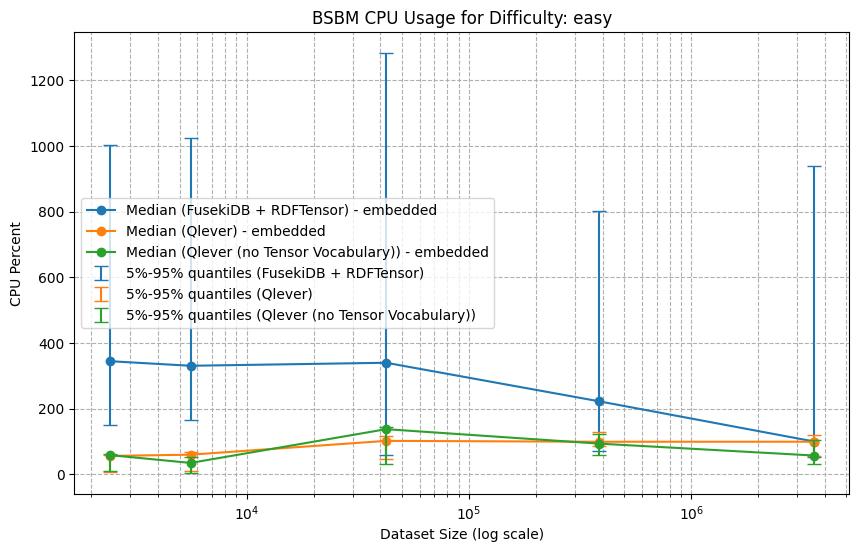

In [ ]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="cpu_percent")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("CPU Percent")
    ax.set_title(f"BSBM CPU Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_cpu_usage.png")
plt.show()


/tmp/ipykernel_4082075/2830796753.py:28: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(


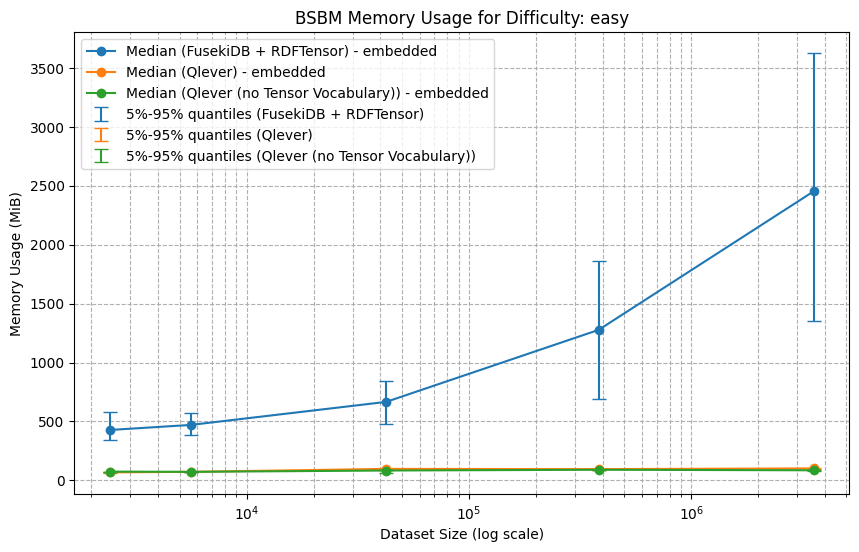

In [ ]:
# plot the stats for the same runs, e.g. number of triples scanned, number of candidates, etc.


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i] if len(difficulties) > 1 else axes
    # set the subtitle to the difficulty

    plot_timings(ax, stats_df, engines, difficulty, relevant_measure="mem_usage_mb")
    ax.set_xscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Memory Usage (MiB)")
    ax.set_title(f"BSBM Memory Usage for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bsbm_mem_usage.png")
plt.show()
